# 🔬 Fingerprint Preprocessing Pipeline — Visual Demo

This notebook demonstrates each step of the preprocessing pipeline on real SOCOFing images.

**Pipeline:** Load → Quality Check → Normalize → Segment → Enhance → Binarize → Thin → Clean

In [1]:
import os
import sys
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Add project root to path
PROJECT_ROOT = Path(os.path.abspath('')).parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.preprocessing import preprocess, load_image, quality_check

DATA_DIR = PROJECT_ROOT / 'data' / 'raw' / 'SOCOFing' / 'Real'
print(f'Project root: {PROJECT_ROOT}')
print(f'Data dir exists: {DATA_DIR.exists()}')

Project root: C:\Users\Avani\OneDrive\Desktop\fingerprint
Data dir exists: True


## 1. Full Pipeline — Step-by-Step Visualization

In [2]:
# Run the full pipeline on a sample image with intermediates
sample_path = str(DATA_DIR / '1__M_Left_index_finger.BMP')
result = preprocess(sample_path, return_intermediates=True)

print(f'Quality passed: {result["quality_passed"]}')
print(f'Quality variance: {result["quality_variance"]:.2f}')
print(f'Skeleton shape: {result["skeleton"].shape}')
print(f'Intermediate keys: {list(result["intermediates"].keys())}')

Quality passed: True
Quality variance: 11338.47
Skeleton shape: (300, 300)
Intermediate keys: ['original', 'normalized', 'mask', 'masked', 'enhanced', 'binary', 'skeleton_raw', 'skeleton_clean']


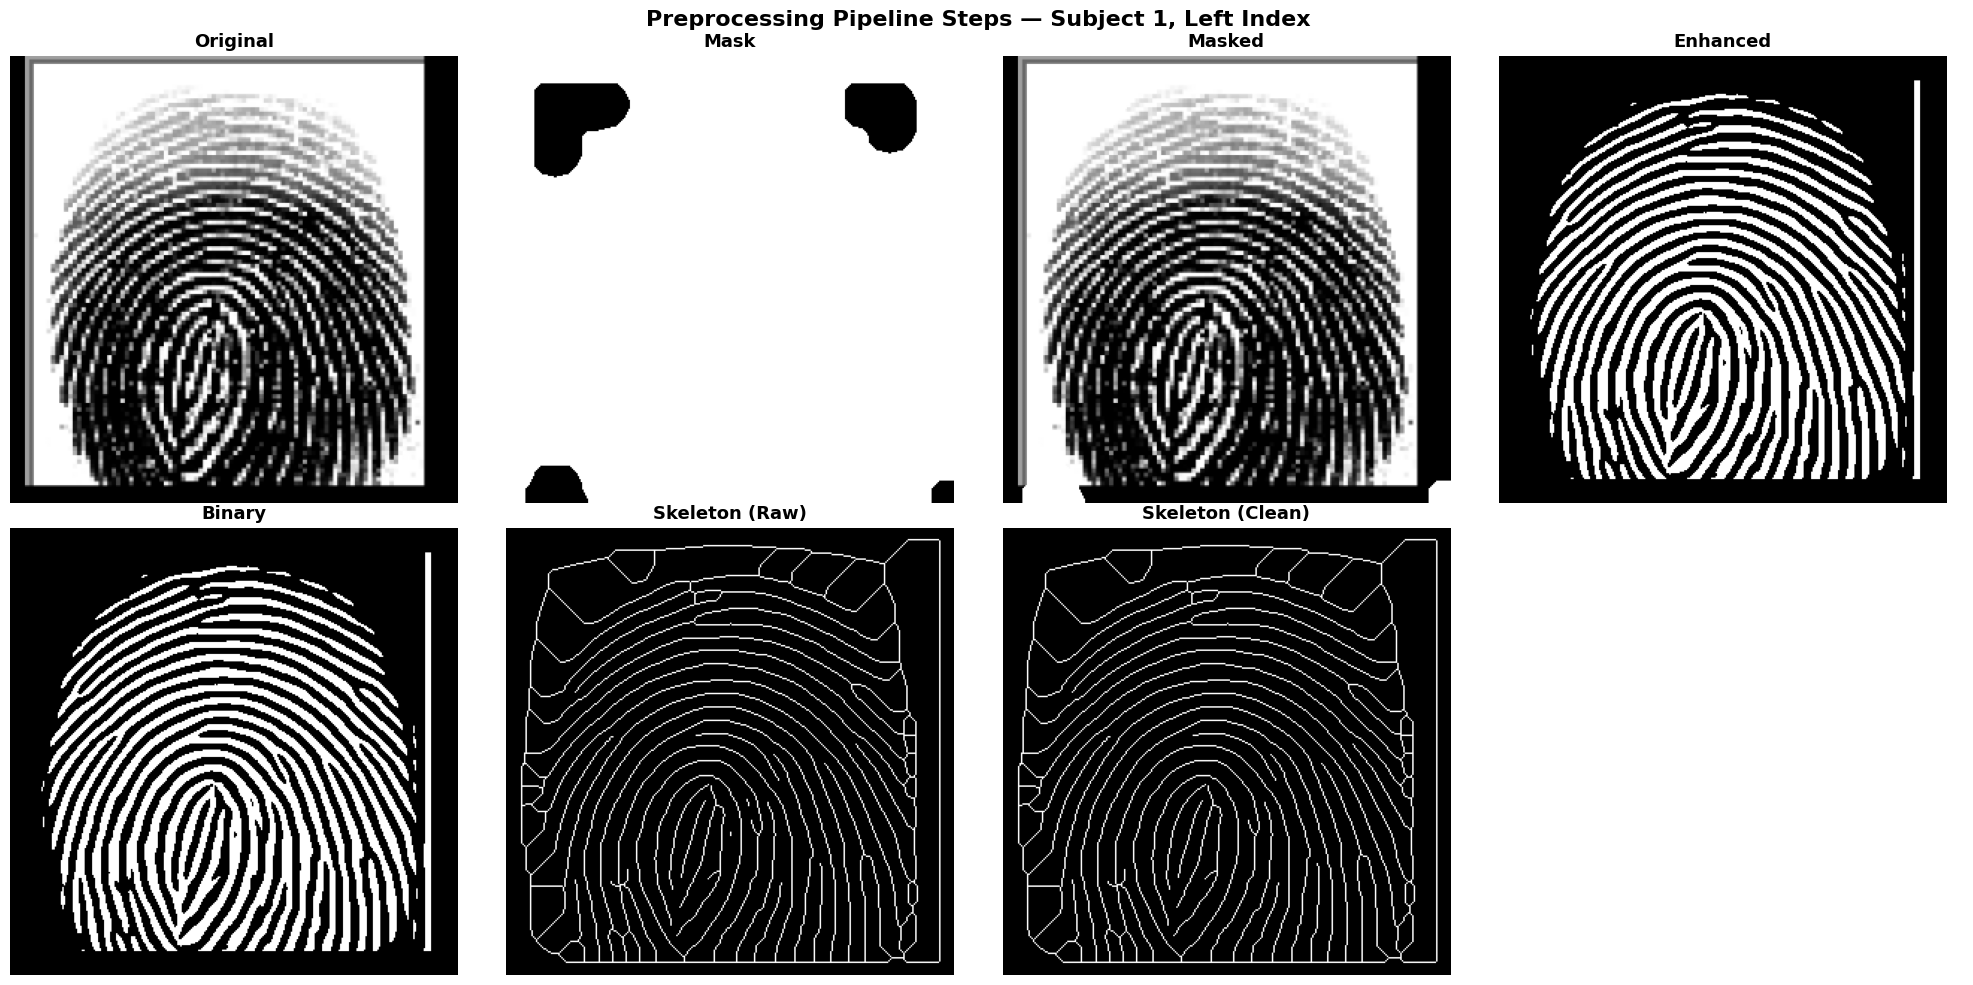

In [3]:
# Visualize each pipeline step
intermediates = result['intermediates']
steps = [
    ('Original', intermediates['original']),
    ('Mask', intermediates['mask']),
    ('Masked', intermediates['masked']),
    ('Enhanced', intermediates['enhanced']),
    ('Binary', intermediates['binary']),
    ('Skeleton (Raw)', intermediates['skeleton_raw']),
    ('Skeleton (Clean)', intermediates['skeleton_clean']),
]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Preprocessing Pipeline Steps — Subject 1, Left Index', fontsize=16, fontweight='bold')

for idx, (title, img) in enumerate(steps):
    row, col = idx // 4, idx % 4
    # Handle normalized image (float) differently
    if img.dtype == np.float64:
        axes[row, col].imshow(img, cmap='gray')
    else:
        axes[row, col].imshow(img, cmap='gray', vmin=0, vmax=255)
    axes[row, col].set_title(title, fontsize=13, fontweight='bold')
    axes[row, col].axis('off')

# Hide the extra subplot
axes[1, 3].axis('off')

plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / 'data' / 'preprocessing_pipeline_demo.png'), dpi=150, bbox_inches='tight')
plt.show()

## 2. Multiple Subjects — Pipeline Comparison

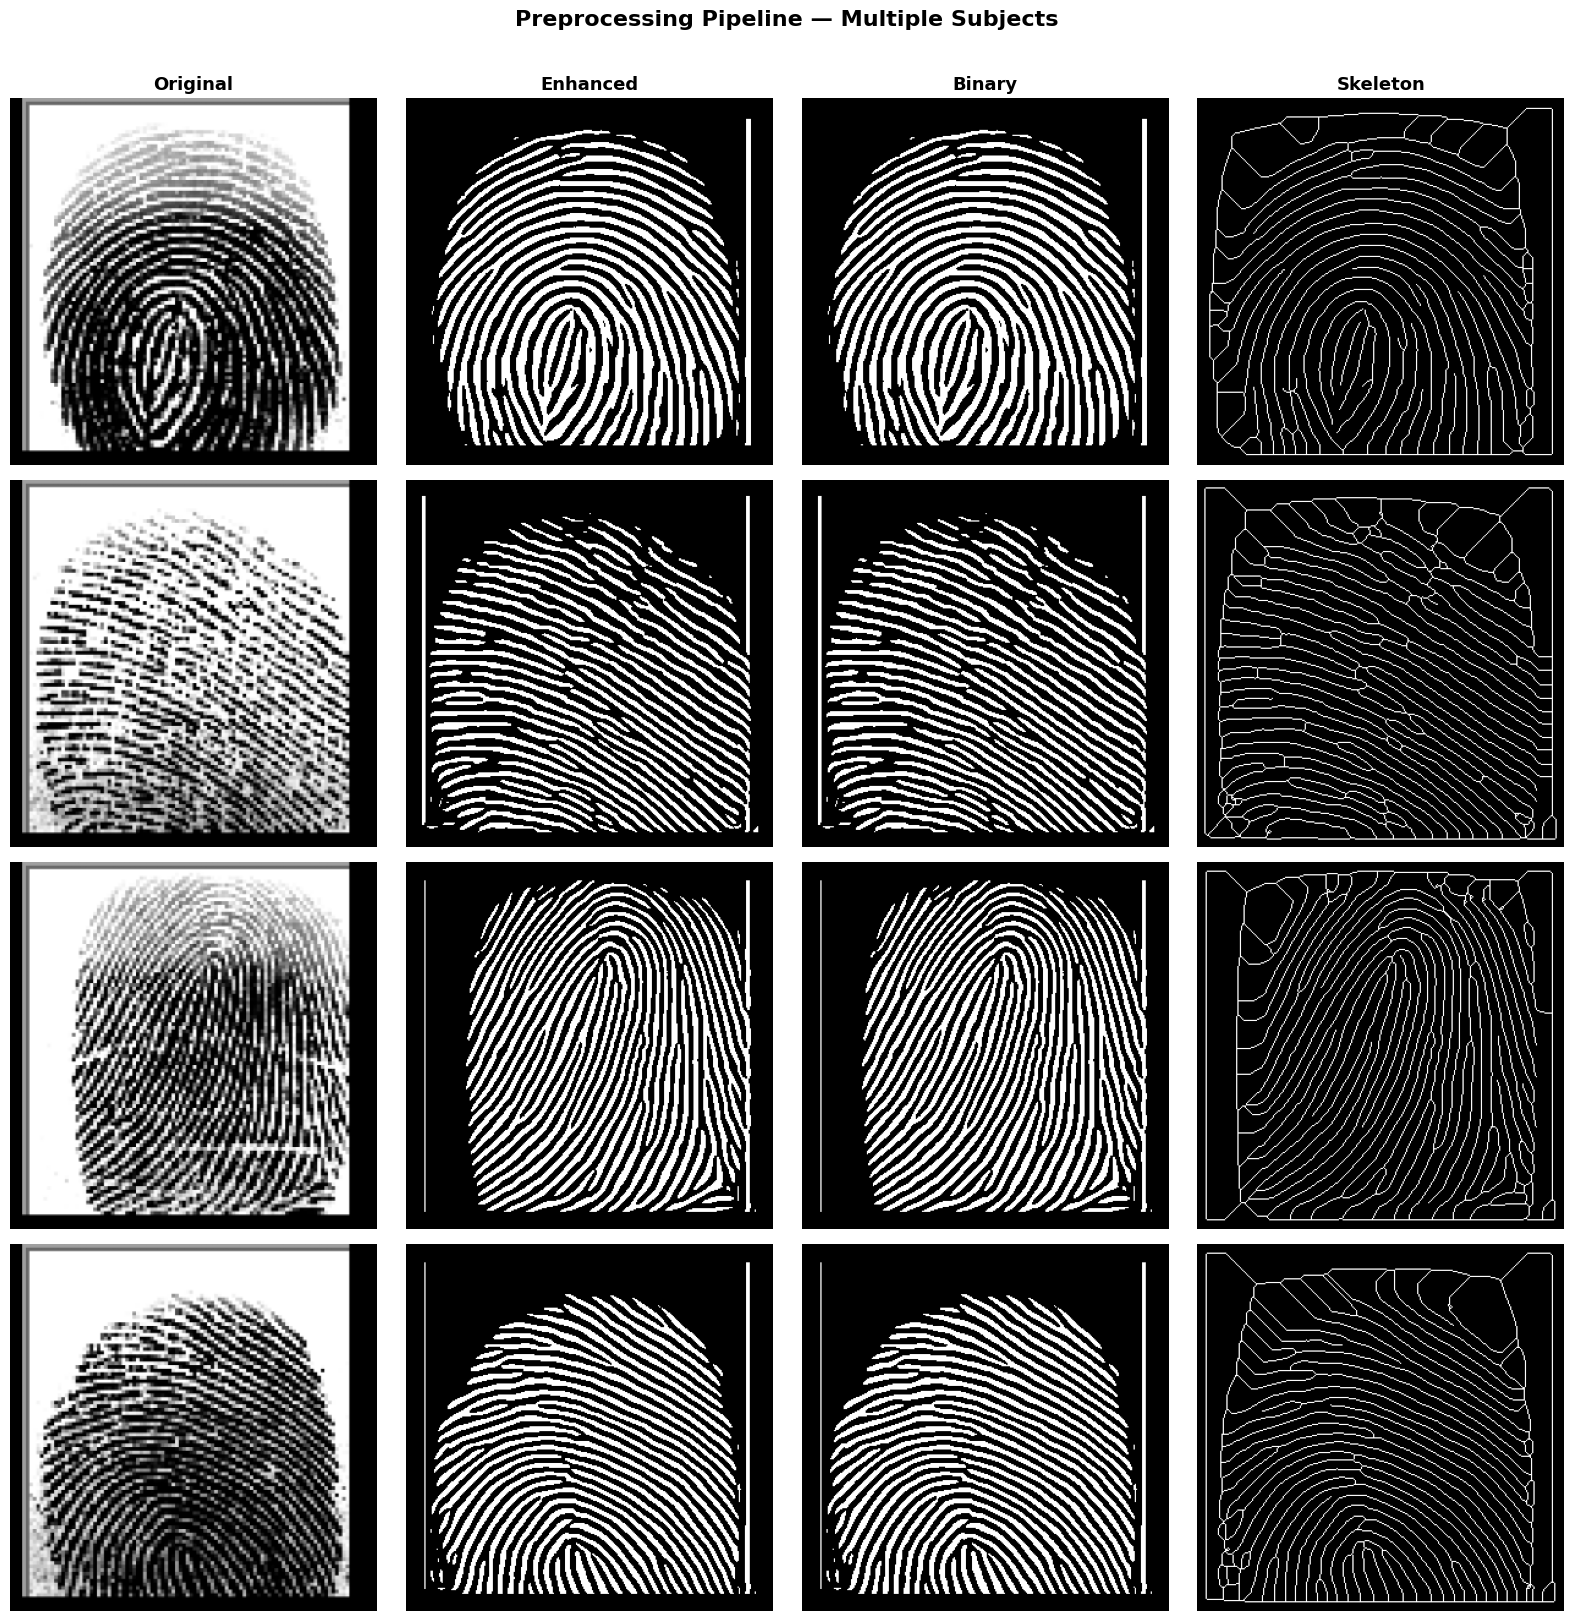

In [4]:
# Run pipeline on multiple subjects for comparison
subjects = [
    ('Subject 1 — Left Index (M)', '1__M_Left_index_finger.BMP'),
    ('Subject 100 — Right Thumb (M)', '100__M_Right_thumb_finger.BMP'),
    ('Subject 103 — Left Middle (F)', '103__F_Left_middle_finger.BMP'),
    ('Subject 400 — Right Index (M)', '400__M_Right_index_finger.BMP'),
]

fig, axes = plt.subplots(len(subjects), 4, figsize=(16, 4 * len(subjects)))
fig.suptitle('Preprocessing Pipeline — Multiple Subjects', fontsize=16, fontweight='bold', y=1.01)

col_titles = ['Original', 'Enhanced', 'Binary', 'Skeleton']

for row_idx, (label, filename) in enumerate(subjects):
    path = str(DATA_DIR / filename)
    r = preprocess(path, return_intermediates=True)
    
    imgs = [
        r['intermediates']['original'],
        r['intermediates']['enhanced'],
        r['intermediates']['binary'],
        r['intermediates']['skeleton_clean'],
    ]
    
    for col_idx, img in enumerate(imgs):
        axes[row_idx, col_idx].imshow(img, cmap='gray', vmin=0, vmax=255)
        if row_idx == 0:
            axes[row_idx, col_idx].set_title(col_titles[col_idx], fontsize=13, fontweight='bold')
        axes[row_idx, col_idx].axis('off')
    
    axes[row_idx, 0].set_ylabel(label, fontsize=11, fontweight='bold', rotation=0, labelpad=120, ha='right')

plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / 'data' / 'preprocessing_multi_subjects.png'), dpi=150, bbox_inches='tight')
plt.show()

## 3. Real vs. Altered — Preprocessing Comparison

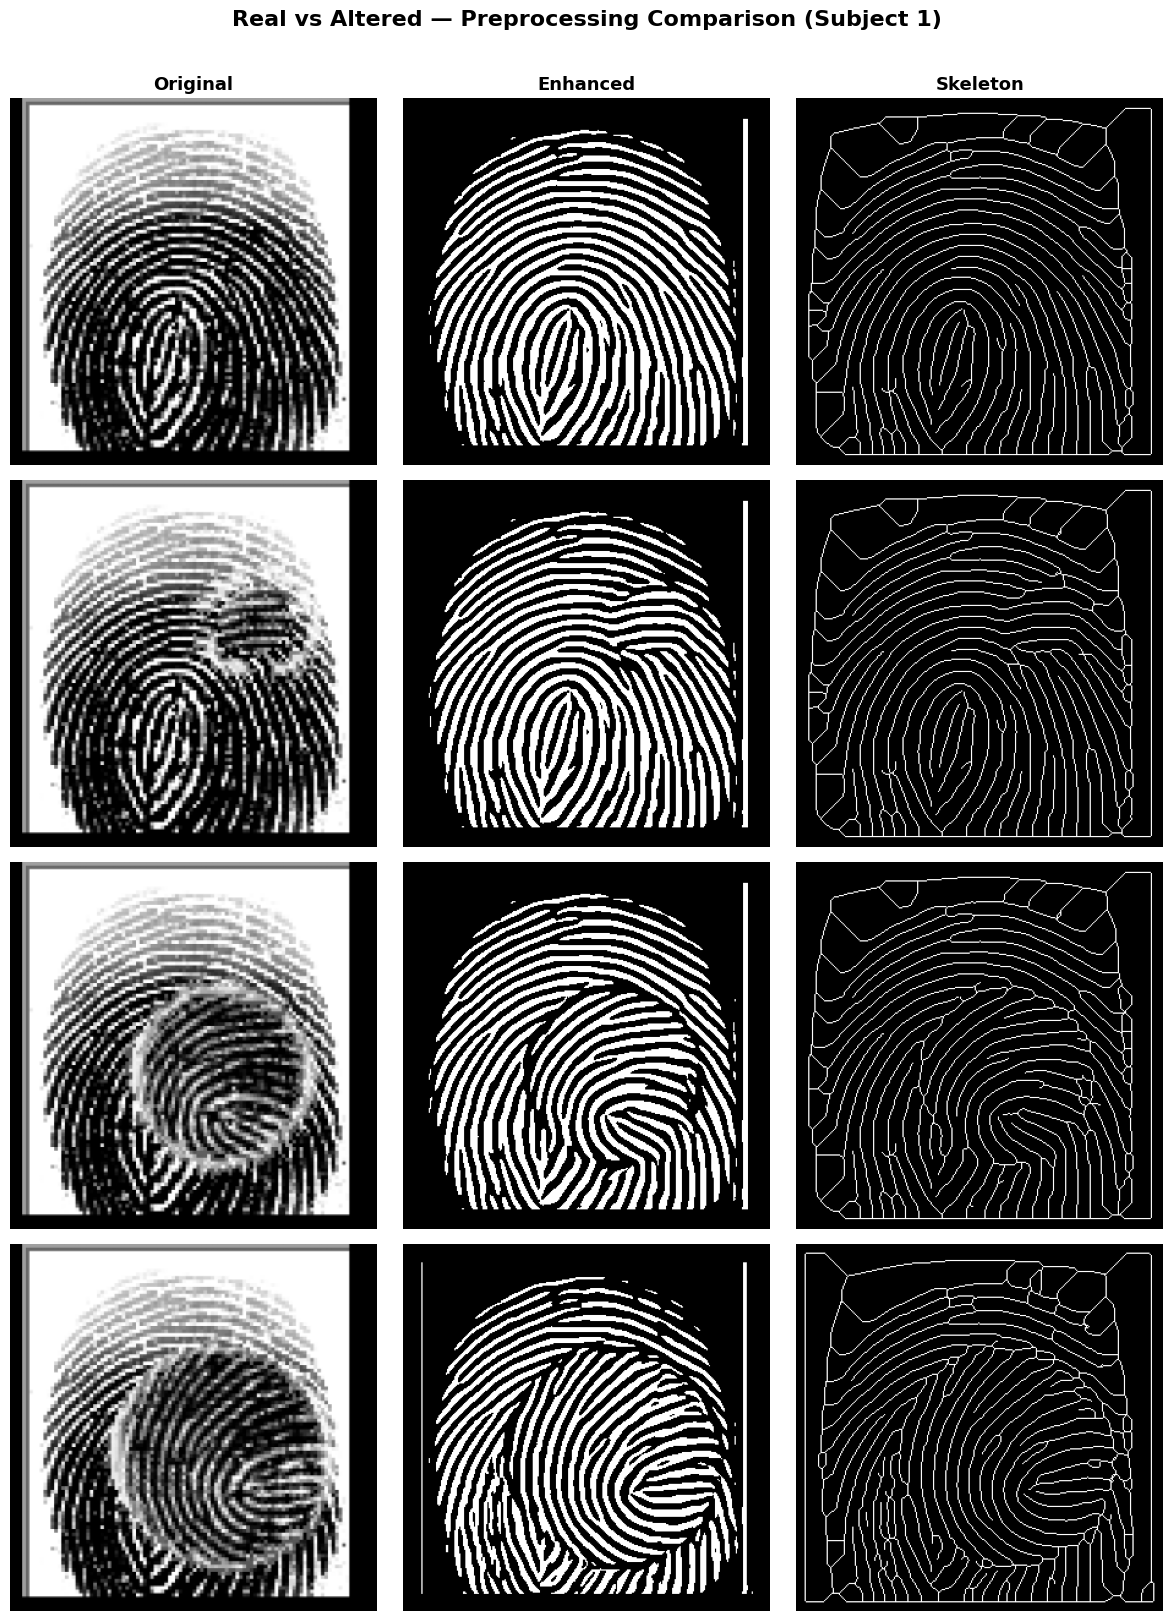

In [5]:
# Compare preprocessing results for Real vs Altered images
import pandas as pd

altered_dir = PROJECT_ROOT / 'data' / 'raw' / 'SOCOFing' / 'Altered'
comparisons = [
    ('Real', str(DATA_DIR / '1__M_Left_index_finger.BMP')),
]

# Find altered versions
for diff in ['Altered-Easy', 'Altered-Medium', 'Altered-Hard']:
    d = altered_dir / diff
    if d.exists():
        # Find any image for subject 1 left index
        matches = [f for f in os.listdir(d) if f.startswith('1__M_Left_index')]
        if matches:
            comparisons.append((diff.replace('Altered-', 'Altered '), str(d / matches[0])))

fig, axes = plt.subplots(len(comparisons), 3, figsize=(12, 4 * len(comparisons)))
fig.suptitle('Real vs Altered — Preprocessing Comparison (Subject 1)', fontsize=16, fontweight='bold', y=1.01)

col_titles = ['Original', 'Enhanced', 'Skeleton']

for row_idx, (label, path) in enumerate(comparisons):
    r = preprocess(path, return_intermediates=True)
    imgs = [
        r['intermediates']['original'],
        r['intermediates']['enhanced'],
        r['intermediates']['skeleton_clean'],
    ]
    for col_idx, img in enumerate(imgs):
        axes[row_idx, col_idx].imshow(img, cmap='gray', vmin=0, vmax=255)
        if row_idx == 0:
            axes[row_idx, col_idx].set_title(col_titles[col_idx], fontsize=13, fontweight='bold')
        axes[row_idx, col_idx].axis('off')
    axes[row_idx, 0].set_ylabel(label, fontsize=11, fontweight='bold', rotation=0, labelpad=100, ha='right')

plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / 'data' / 'preprocessing_real_vs_altered.png'), dpi=150, bbox_inches='tight')
plt.show()

## 4. Quality Check — Batch Statistics

Checked 200 images
Quality passed: 200/200 (100.0%)
Variance range: 7415.1 - 13625.4
Mean variance: 10643.9


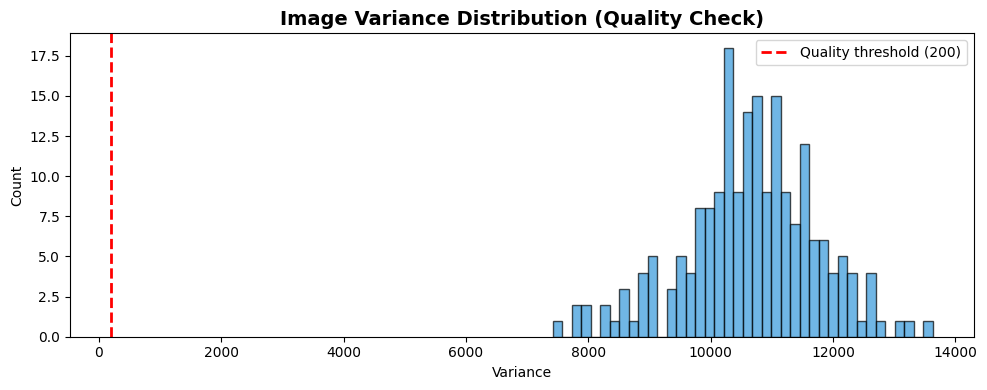

In [6]:
# Run quality check on a random sample of images
import random
random.seed(42)

all_real = sorted([f for f in os.listdir(DATA_DIR) if f.endswith('.BMP')])
sample = random.sample(all_real, min(200, len(all_real)))

variances = []
passed_count = 0

for fn in sample:
    img = load_image(str(DATA_DIR / fn), target_size=(300, 300))
    passed, var = quality_check(img)
    variances.append(var)
    if passed:
        passed_count += 1

print(f'Checked {len(sample)} images')
print(f'Quality passed: {passed_count}/{len(sample)} ({100*passed_count/len(sample):.1f}%)')
print(f'Variance range: {min(variances):.1f} - {max(variances):.1f}')
print(f'Mean variance: {np.mean(variances):.1f}')

plt.figure(figsize=(10, 4))
plt.hist(variances, bins=40, color='#3498db', alpha=0.7, edgecolor='black')
plt.axvline(x=200, color='red', linestyle='--', linewidth=2, label='Quality threshold (200)')
plt.title('Image Variance Distribution (Quality Check)', fontsize=14, fontweight='bold')
plt.xlabel('Variance')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / 'data' / 'quality_check_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. Summary

### Pipeline Steps:
1. **Load** — Grayscale, resized to 300×300 with aspect ratio preservation
2. **Quality Check** — Variance-based rejection (threshold=200)
3. **Normalize** — Zero-mean, unit-variance
4. **Segment** — Block-wise variance mask with morphological cleanup
5. **Enhance** — `fingerprint_enhancer` library (Gabor-based ridge enhancement)
6. **Binarize** — Otsu adaptive thresholding
7. **Thin** — Skeletonization to 1-pixel ridges
8. **Clean** — Remove spurious short branches

### Next Steps:
- Phase 3: Minutiae detection using Crossing Number algorithm on the skeleton